<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/Semana-4-Actividad-3-Aplicaci-n-de-T-cnicas-de-Optimizaci-n-en-una-Red-Neuronal-en-Google-Colab-/blob/main/Semana%204%20%E2%80%93%20Actividad%203%3A%20Aplicaci%C3%B3n%20de%20T%C3%A9cnicas%20de%20Optimizaci%C3%B3n%20en%20una%20Red%20Neuronal%20en%20Google%20Colab%E2%80%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Configuración LR=0.1 completada.
Configuración LR=0.8 completada.


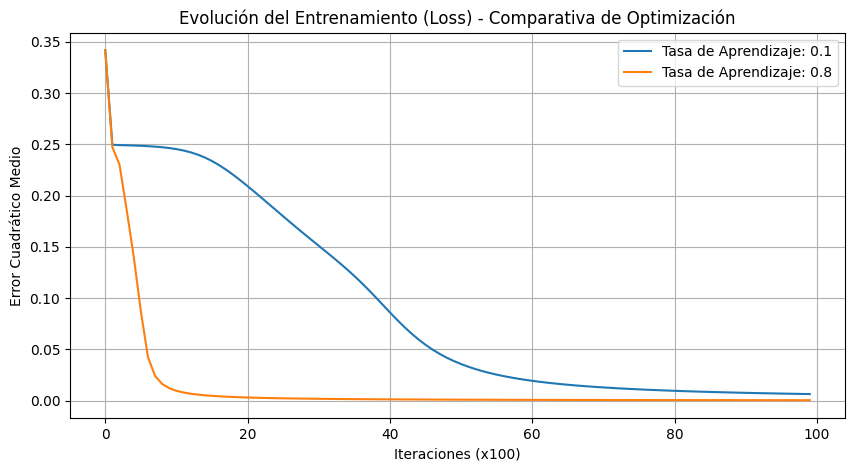

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Funciones de activación
def sigmoid(x): return 1 / (1 + np.exp(-x))
def sigmoid_deriva(x): return x * (1 - x)

# 2. Dataset XOR (Clasificación Binaria)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

# 3. Proceso de Entrenamiento (Modelo Base)
def entrenar_modelo(tasa_aprendizaje, epocas=10000):
    np.random.seed(42)
    # Inicialización constante para validación técnica
    w_h = np.random.uniform(size=(2, 4))
    w_o = np.random.uniform(size=(4, 1))
    historial_loss = []

    for epoca in range(epocas):
        # Forward
        capa_h = sigmoid(np.dot(X, w_h))
        prediccion = sigmoid(np.dot(capa_h, w_o))

        # Backpropagation
        error = y - prediccion
        d_salida = error * sigmoid_deriva(prediccion)
        d_oculto = (d_salida.dot(w_o.T)) * sigmoid_deriva(capa_h)

        # Actualización (Optimización)
        w_o += capa_h.T.dot(d_salida) * tasa_aprendizaje
        w_h += X.T.dot(d_oculto) * tasa_aprendizaje

        if epoca % 100 == 0:
            historial_loss.append(np.mean(np.square(error)))

    return historial_loss, prediccion

# 4. Comparación de Configuraciones (Criterio 2 y 3)
tasas = [0.1, 0.8] # Configuración A (Lenta/Estable) vs B (Rápida/Agresiva)
resultados = {}

for tasa in tasas:
    loss, pred = entrenar_modelo(tasa)
    resultados[tasa] = {"loss": loss, "pred": pred}
    print(f"Configuración LR={tasa} completada.")

# 5. Evidencia Visible: Gráfico de Convergencia
plt.figure(figsize=(10, 5))
for tasa in tasas:
    plt.plot(resultados[tasa]["loss"], label=f"Tasa de Aprendizaje: {tasa}")
plt.title("Evolución del Entrenamiento (Loss) - Comparativa de Optimización")
plt.xlabel("Iteraciones (x100)")
plt.ylabel("Error Cuadrático Medio")
plt.legend()
plt.grid(True)
plt.show()

(i) Diferencias observadas:
La configuración con tasa 0.8 alcanza el error mínimo mucho antes que la de 0.1.

(ii) Estabilidad y velocidad:
La tasa de 0.1 muestra una curva de aprendizaje más estable, mientras que la de 0.8 es más agresiva. En datasets más complejos, una tasa muy alta podría causar inestabilidad u oscilaciones, pero aquí favorece la velocidad.

(iii) Hallazgos y dificultades:
 La mayor dificultad técnica radica en encontrar el equilibrio